### M-DART PAPER: FIGURE 1 AND STATS

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

plt.rcParams['pdf.fonttype'] = 42  # To embed fonts in PDF output (for Illustrator compatibility)
plt.rcParams['font.family'] = 'Arial'

In [2]:
# ---- Helpers ----
def compute_demean_range01(vals, observed_min=None, observed_max=None):
    if observed_min == None:
        observed_min = np.min(vals)
    if observed_max == None:
        observed_max = np.max(vals)
    # scale 0-1
    model_vals = (vals-observed_min) / ( observed_max - observed_min )
    # subtract mean
    model_vals = model_vals-np.mean(model_vals)
    # zero center
    model_vals = 2*(model_vals-np.mean(model_vals))
    return model_vals

def p_to_stars(p: float, show_ns: bool = False) -> str:
    """Convert p-value to significance stars."""
    
    if p is None or np.isnan(p):
        return ""

    # threshold : star label
    p_dict = {
        1e-4: "****",    # p < 0.0001
        1e-3: "***",     # p < 0.001
        1e-2: "**",      # p < 0.01
        5e-2: "*",       # p < 0.05
    }

    # iterate in ascending order of thresholds
    for threshold in sorted(p_dict):
        if p < threshold:
            return p_dict[threshold]

    return "ns" if show_ns else ""

def _draw_contrast(ax, x1, x2, y, stars,
                   line_lw=0.45, star_fs=6,
                   star_pad_pts=1.5,   # <-- NEW: star offset in points
                   y_pad_frac=0.0):    # optional: additional offset as fraction of y-range
    """
    Draw a single contrast bracket and star label.

    star_pad_pts: vertical gap between the line and the stars in points (recommended control).
    y_pad_frac:   additional vertical gap in data units as fraction of y-range (optional).
    """
    # Get y-range for optional fractional padding
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin

    # Draw the bracket line
    ax.plot([x1, x1, x2, x2], [y, y, y, y], lw=line_lw, c="black")

    # Place stars: right above the line
    x_mid = (x1 + x2) / 2.0
    y_star = y + y_pad_frac * yr

    ax.annotate(
        stars,
        xy=(x_mid, y_star),
        xytext=(0, star_pad_pts),  # <-- gap above line, in points
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=star_fs,
    )

def add_contrast_lines_and_stars(ax, comparisons,
    y_base=None,
    base_pad_frac=0.09,
    step_frac=0.12,
    line_lw=0.45,
    star_fs=6,
    star_pad_pts=1.5,  # <-- NEW
    y_pad_frac=0.0,    # keep if you want (I’d default to 0 now)
    expand_ylim=True,):
    """
    Draw ONE OR MULTIPLE contrast lines + stars on a bar plot.

    Parameters
    ----------
    comparisons:
        Either:
          - a single tuple (x1, x2, stars)
          - OR a list/iterable of tuples [(x1, x2, stars), ...]
        `x1` and `x2` are x-locations (bar centers), `stars` is a string (e.g., "*", "ns", "").

    y_base: Where to start stacking lines (in data units). If None, it auto-detects the tallest bar.

    base_pad_frac: Fraction of y-axis range to add above y_base for the first line.

    step_frac: Fraction of y-axis range added per additional comparison line.

    expand_ylim: If True, expands y-limits upward so the top stars are not clipped.
    """

    # Filter out empty star entries
    comps = [(x1, x2, s) for (x1, x2, s) in comparisons if s]
    if not comps:
        return

    # Get current y-range to convert fractions into data units
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin

    # Auto-pick y_base if not provided
    if y_base is None:
        bar_tops = [p.get_height() for p in ax.patches]
        # If there are bars, start above the tallest bar. Otherwise fall back to ymax.
        y_base = max(bar_tops) if bar_tops else ymax

    # First line starts at y0, above y_base by base_pad_frac of the y-range.
    y0 = y_base + base_pad_frac * yr

    # Draw each comparison, stacking vertically with step_frac spacing
    for i, (x1, x2, stars) in enumerate(comps):
        y = y0 + i * step_frac * yr
        _draw_contrast(
            ax=ax, x1=x1, x2=x2, y=y, stars=stars,
            line_lw=line_lw, star_fs=star_fs, y_pad_frac=y_pad_frac, star_pad_pts=star_pad_pts
        )

    # Optionally expand y-limits so stars aren’t clipped
    if expand_ylim:
        # The highest line is the last one: i = len(comps)-1
        top_line_y = y0 + (len(comps) - 1) * step_frac * yr

        # Add extra headroom for the text above that line.
        top_needed = top_line_y + (y_pad_frac + 0.03) * yr

        if top_needed > ymax:
            ax.set_ylim(ymin, top_needed)

def save_figure(
    fig,
    out_dir,
    filename,
    dpi=600,
    save_pdf=True,
    save_png=True,
    facecolor="white",
    bbox_inches="tight",
):
    """ Save figure in PDF and PNG format."""

    if save_pdf:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.pdf"),
            bbox_inches=bbox_inches,
        )

    if save_png:
        fig.savefig(
            os.path.join(out_dir, f"{filename}.png"),
            dpi=dpi,
            bbox_inches=bbox_inches,
            facecolor=facecolor,
        )

# -----------------------------
# Plotting constants
# -----------------------------
colors_dict1 = {
    "p_risk": "#ff5aa7",   # pink
    "r_risk": "#d98c00",   # orange
    "a_amb":  "#9fd3e6",   # light blue
}

order = ["p_risk", "r_risk", "a_amb"]
regressor_labels = {"p_risk": "Probability", "r_risk": "Risk", "a_amb": "Ambiguity"}

#### Figure 1, Panel c & d:

In [3]:
data_dir = Path("../data/figure1")
fig_out_dir = Path(r"C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures")

beh_df = pd.read_csv(data_dir / "behavioral_data.csv")
print(beh_df.shape)

(13736, 30)


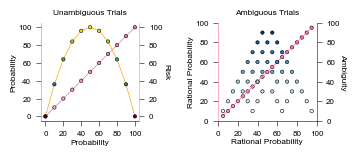

In [4]:
# -------------------------
# 1. Build plotting tables
# -------------------------

# Risk trials (known probability)
non_amb = beh_df.loc[
    beh_df["TrialType"].isin(["risk", "certain"]),
    ["p_risk", "r_risk"]
].dropna()

# Unique points (design levels) for plotting
non_amb = non_amb.drop_duplicates().sort_values("p_risk")

# Ambiguity trials
amb = beh_df.loc[
    beh_df["TrialType"] == "amb",
    ["rational_p_amb", "a_amb"]
].dropna()

amb_structure = amb.drop_duplicates().copy()  # keep unique pairs
amb_scaffold = (
    amb_structure[["rational_p_amb"]]
    .drop_duplicates()
    .sort_values("rational_p_amb")
)

# -------------------------
# 2. Plot
# -------------------------

fig1_c_and_d, axes = plt.subplots(
    1, 2,
    figsize=(70/25.4, 30/25.4),  # 65/25.4, 30/25.4: for manuscript; 120/25.4, 30/25.4 for presentation
    gridspec_kw={'width_ratios': [1, 1]}
)

plt.subplots_adjust(
    left=0,
    right=1,
    bottom=0.12,
    top=0.95,
    wspace=0.8 # for presentation 0.6; 0.8 for presentation
)


custom_palette = sns.blend_palette(["lightpink", "hotpink"], as_cmap=True)

# ===== Left panel: Risk trials =====
ax = axes[0]

# Scaffold: p_risk identity (pink)
sns.scatterplot(
    x=non_amb["p_risk"], y=non_amb["p_risk"],
    hue=non_amb["p_risk"], palette=custom_palette,
    edgecolor="black", linewidth=0.4,
    s=6, legend=False, zorder=30, ax=ax
)
sns.lineplot(x="p_risk", y="p_risk", data=non_amb, color="hotpink", linewidth=0.5, ax=ax)

# Structure: r_risk vs p_risk on a twin axis (orange/viridis)
ax1 = ax.twinx()
sns.scatterplot(
    x=non_amb["p_risk"], y=non_amb["r_risk"],
    hue=non_amb["r_risk"], palette="viridis",
    edgecolor="black", linewidth=0.4,
    s=6, legend=False, zorder=30, ax=ax1
)
sns.lineplot(x="p_risk", y="r_risk", data=non_amb, color="orange", linewidth=0.5, ax=ax1)

ax.set_title("Unambiguous Trials", fontsize=6, fontdict={"family": "Arial"})
ax.set_xlabel("Probability", fontsize=6, labelpad=1.5, fontdict={"family": "Arial"})
ax.set_ylabel("Probability", fontsize=6, labelpad=1, fontdict={"family": "Arial"})
ax1.set_ylabel('Risk', fontsize=6, labelpad=5, fontdict={"family": "Arial"}, rotation=270)

ax.spines["left"].set_color("hotpink")
ax1.spines["right"].set_color("orange")

ax.set_xticks(np.arange(0, 101, 20))
ax.set_yticks(np.arange(0, 101, 20))
ax1.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis='x', labelsize=5.8, width=0.4)
ax.tick_params(axis='y', labelsize=5.8, width=0.4)
ax1.tick_params(axis='y', labelsize=5.8, width=0.4)

# cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["left"].set_visible(False)
ax1.spines["bottom"].set_visible(False)

# ===== Right panel: Ambiguity trials =====
ax2 = axes[1]

# Rational_p_amb identity (pink) — unique x-levels only
sns.scatterplot(
    x=amb_scaffold["rational_p_amb"], y=amb_scaffold["rational_p_amb"],
    hue=amb_scaffold["rational_p_amb"], palette=custom_palette,
    edgecolor="black", linewidth=0.4,
    s=6, legend=False, zorder=30, ax=ax2
)

ax3 = ax2.twinx()

# Ambiguity vs rational probability (blue) — keep unique pairs
sns.scatterplot(
    x=amb_structure["rational_p_amb"], y=amb_structure["a_amb"],
    hue=amb_structure["a_amb"], palette="Blues",
    edgecolor="black", linewidth=0.4,
    s=6, legend=False, zorder=30, ax=ax3
)

# Identity line for rational probability
sns.lineplot(x="rational_p_amb", y="rational_p_amb", data=amb_scaffold, color="hotpink", linewidth=0.5, ax=ax3)

ax2.set_title("Ambiguous Trials", fontsize=6, fontdict={"family": "Arial"})
ax2.set_xlabel('Rational Probability', fontsize=6, labelpad=1, fontdict={"family": "Arial"})
ax2.set_ylabel('Rational Probability', fontsize=6, labelpad=1, fontdict={"family": "Arial"})
ax3.set_ylabel('Ambiguity', fontsize=6, labelpad=5, fontdict={"family": "Arial"}, rotation=270)

ax2.spines["left"].set_color("hotpink")
ax3.spines["right"].set_color("darkblue")

ax2.set_xticks(np.arange(0, 101, 20))
ax2.set_yticks(np.arange(0, 101, 20))
ax3.set_yticks(np.arange(0, 101, 20))
ax2.tick_params(axis='x', labelsize=5.8, width=0.4)
ax2.tick_params(axis='y', labelsize=5.8, width=0.4)
ax3.tick_params(axis='y', labelsize=5.8, width=0.4)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax3.spines["top"].set_visible(False)
ax3.spines["left"].set_visible(False)
ax3.spines["bottom"].set_visible(False)

for axis in (ax, ax1, ax2, ax3):
    for spine in axis.spines.values():
        spine.set_linewidth(0.4)


plt.show()

save_figure(
    fig=fig1_c_and_d,
    out_dir=fig_out_dir,
    filename="Fig1_c&d_task_space",
    dpi=600,
    save_pdf=True,
    save_png=True,
    facecolor="white",
    bbox_inches="tight",
)

#### Figure 1, Panel e-g:


In [5]:
# ----------------------------
# 1) Subject-level condition means
# ----------------------------

beh_df_subj = (
    beh_df
    .groupby(['TrialType', 'subject', 'ThreatPct', 'AmbiguousPct', 'RationalAmb'], as_index=False)
    .mean(numeric_only=True)
)

# Helper: group mean + SD + SEM + 95% CI
def mean_sem(df, xcol, ycol="RatingValue"):
    out = (
        df.groupby(xcol)[ycol]
          .agg(mean="mean", std="std", n="count")
          .reset_index()
          .sort_values(xcol)
    )

    # Standard error of the mean
    out["sem"] = out["std"] / np.sqrt(out["n"])

    # 95% confidence interval 
    tval = stats.t.ppf(0.975, df=out["n"] - 1)
    out["ci95"] = tval * out["sem"]

    # 68% confidence interval
    tval68 = stats.t.ppf(0.84, df=out["n"] - 1)
    out["ci68"] = tval68 * out["sem"]

    return out


# ----------------------------
# 2) Build the three plotting tables
# ----------------------------

# (A) Probability panel: use risk + certain, x = ThreatPct
df_prob = beh_df_subj[beh_df_subj["TrialType"].isin(["risk", "certain"])].copy()
prob_sum = mean_sem(df_prob, "ThreatPct")

# (B) Risk panel: risk only, x = r_risk (collapses symmetric probs: 10 & 90 -> 36)
df_risk = beh_df_subj[beh_df_subj["TrialType"] == "risk"].copy()
risk_sum = mean_sem(df_risk, "r_risk")

# (C) Ambiguity panel: amb only, x = AmbiguousPct
df_amb = beh_df_subj[beh_df_subj["TrialType"] == "amb"].copy()
amb_sum = mean_sem(df_amb, "AmbiguousPct")

# ----------------------------
# 3) Plot
# ----------------------------
def plot_prob_panel(ax, prob_sum, colors_dict):
    x = prob_sum["ThreatPct"].values
    y = prob_sum["mean"].values
    errbar = prob_sum["sem"].values

    ax.bar(x, y, width=7, color=colors_dict["p_risk"])
    ax.errorbar(x, y, yerr=errbar, fmt="none", ecolor="black", linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_xlabel("Probability", fontsize=6, labelpad=1.5, fontdict={"family": "Arial"})
    ax.set_ylabel("Distress Rating", fontsize=6, labelpad=1, fontdict={"family": "Arial"})
    ax.set_xticks(sorted(prob_sum["ThreatPct"].unique()))
    ax.set_xticklabels([f"{int(t)}" for t in sorted(prob_sum["ThreatPct"].unique())], fontsize=5.8, fontdict={"family": "Arial"})

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f"{int(v)}" for v in ax.get_yticks()], fontsize=5.8, fontdict={"family": "Arial"})
    ax.tick_params(axis="y", labelsize=5.8, pad=0.5)
    ax.tick_params(axis="x", labelsize=5.8, pad=0.5)
    ax.margins(x=0.02, y=0.02)
    #add_panel_label(ax, "e", y=1.025)

    _style_axes(ax)


def plot_risk_panel(ax, risk_sum, colors_dict):
    labels = risk_sum["r_risk"].values
    x_pos = np.arange(len(labels))

    y = risk_sum["mean"].values
    errbar = risk_sum["sem"].values

    ax.bar(x_pos, y, width=0.75, color=colors_dict["r_risk"])
    ax.errorbar(x_pos, y, yerr=errbar, fmt="none", ecolor="black", linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_xlabel("Risk", fontsize=6, labelpad=1.5, fontdict={"family": "Arial"})
    ax.set_ylabel("Distress Rating", fontsize=6, labelpad=1, fontdict={"family": "Arial"})
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{int(l)}" for l in labels], fontsize=5.8, fontdict={"family": "Arial"})
    ax.tick_params(axis="x", labelsize=5.8, pad=0.5)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f"{int(v)}" for v in ax.get_yticks()], fontsize=5.8, fontdict={"family": "Arial"})
    ax.tick_params(axis="y", labelsize=5.8, pad=0.5)
    
    ax.margins(x=0.02, y=0.02)
    #add_panel_label(ax, "f")
    _style_axes(ax)


def plot_amb_panel(ax, amb_sum, colors_dict):
    x = amb_sum["AmbiguousPct"].values
    y = amb_sum["mean"].values
    errbar = amb_sum["sem"].values

    ax.bar(x, y, width=7, color=colors_dict["a_amb"])
    ax.errorbar(x, y, yerr=errbar, fmt="none", ecolor="black", linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_xlabel("Ambiguity", fontsize=6, labelpad=1.5, fontdict={"family": "Arial"})
    ax.set_ylabel("Distress Rating", fontsize=6, labelpad=1, fontdict={"family": "Arial"})
    ax.set_xticks(sorted(amb_sum["AmbiguousPct"].unique()))
    ax.set_xticklabels([f"{int(a)}" for a in sorted(amb_sum["AmbiguousPct"].unique())], fontsize=5.8, fontdict={"family": "Arial"})
    ax.tick_params(axis="x", labelsize=5.8, pad=0.5)

    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f"{int(v)}" for v in ax.get_yticks()], fontsize=5.8, fontdict={"family": "Arial"})
    ax.tick_params(axis="y", labelsize=5.8, pad=0.5)
    ax.margins(x=0.02, y=0.02)
    #add_panel_label(ax, "g")
    _style_axes(ax)


def _style_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.spines["left"].set_linewidth(0.4)
    ax.tick_params(axis="both", which="both", width=0.4)

##### Statistics of Figure 1, Panel e-g:

In [6]:
# --- Combined model: Probability + Risk (certain/risk trials) and Ambiguity + Rational Probability (ambiguous trials) ---

# 1) Certain/risk rows: keep p_risk, r_risk; zero out the ambiguous-only predictors
data_risk_block = beh_df[beh_df["TrialType"].isin(["risk", "certain"])][
    ["RatingValue", "TrialType", "p_risk", "r_risk", "subject"]
].dropna(subset=["RatingValue", "p_risk", "r_risk", "subject"]).copy()

# 2) Ambiguous rows: keep a_amb, rational_p_amb; zero out the risk-only predictors
data_amb_block = beh_df[beh_df["TrialType"] == "amb"][
    ["RatingValue", "TrialType", "a_amb", "rational_p_amb", "subject"]
].dropna(subset=["RatingValue", "a_amb", "rational_p_amb", "subject"]).copy()

# 3) Demean/range01 each predictor within its own domain (whole-sample, not per-subject),
#    on the real trials only -- before the zero placeholders for the other block are added
data_risk_block["p_risk"] = compute_demean_range01(data_risk_block["p_risk"])
data_risk_block["r_risk"] = compute_demean_range01(data_risk_block["r_risk"])
data_amb_block["a_amb"] = compute_demean_range01(data_amb_block["a_amb"])
data_amb_block["rational_p_amb"] = compute_demean_range01(data_amb_block["rational_p_amb"])

# 4) Now add the zero placeholders for the other block's predictors
data_risk_block["a_amb"] = 0.0
data_risk_block["rational_p_amb"] = 0.0
data_risk_block["TrialTypeGroup"] = "certain_risk"

data_amb_block["p_risk"] = 0.0
data_amb_block["r_risk"] = 0.0
data_amb_block["TrialTypeGroup"] = "amb"

# 5) Combine into one long dataframe
data_combined = pd.concat([data_risk_block, data_amb_block], ignore_index=True)
data_combined["TrialTypeGroup"] = pd.Categorical(
    data_combined["TrialTypeGroup"], categories=["certain_risk", "amb"], ordered=False
)

# 6) Fit combined mixed-effects model
mdl_combined = smf.mixedlm(
    "RatingValue ~ C(TrialTypeGroup, Treatment(reference='certain_risk')) + p_risk + r_risk + a_amb + rational_p_amb",
    data=data_combined,
    groups=data_combined["subject"]
).fit()
print(mdl_combined.summary())


                                 Mixed Linear Model Regression Results
Model:                             MixedLM                Dependent Variable:                RatingValue
No. Observations:                  10492                  Method:                            REML       
No. Groups:                        101                    Scale:                             0.9168     
Min. group size:                   97                     Log-Likelihood:                    -14645.8326
Max. group size:                   104                    Converged:                         Yes        
Mean group size:                   103.9                                                                
--------------------------------------------------------------------------------------------------------
                                                              Coef. Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------

#### Figure 1, Panel h & i:


In [7]:
# -----------------------------
# Core helpers
# -----------------------------
order2 = ["Probability", "Risk", "Ambiguity"]
colors_dict = {
    "Probability": "#ff5aa7",   # pink
    "Risk": "#d98c00",   # orange
    "Ambiguity":  "#9fd3e6",   # light blue
}

def compute_within_subject_betas(
    beh_df: pd.DataFrame,
    ycol: str,
    subject_col: str = "subject",
    trialtype_col: str = "TrialType",
) -> pd.DataFrame:
    """
    For each subject, fit ONE combined model on that subject's risk/certain
    and ambiguous trials stacked together, using zero-placeholders for the
    other block's predictors and a trial-type-group dummy so each block gets
    its own intercept:
      y ~ C(TrialTypeGroup, ref='certain_risk') + p_risk + r_risk + a_amb + rational_p_amb
    This gives identical p_risk/r_risk/a_amb coefficients to fitting two
    separate OLS models per subject (verified numerically), while pooling
    residual variance across both blocks instead of keeping it separate.
    Returns wide betas dataframe: columns = [subject, Probability, Risk, Ambiguity]
    """

    risk_trials = (
        beh_df.loc[
            beh_df[trialtype_col].isin(["risk", "certain"]),
            [subject_col, ycol, "p_risk", "r_risk"],
        ]
        .dropna()
    )

    amb_trials = (
        beh_df.loc[
            beh_df[trialtype_col] == "amb",
            [subject_col, ycol, "rational_p_amb", "a_amb"],
        ]
        .dropna()
    )

    # subjects with data in both subsets
    subjects = sorted(set(risk_trials[subject_col]).intersection(amb_trials[subject_col]))

    rows = []
    for s in subjects:
        d_risk = risk_trials[risk_trials[subject_col] == s].copy()
        d_amb = amb_trials[amb_trials[subject_col] == s].copy()

        # rescale each predictor within its own domain, within this subject
        d_risk["p_risk"] = compute_demean_range01(d_risk["p_risk"].to_numpy())
        d_risk["r_risk"] = compute_demean_range01(d_risk["r_risk"].to_numpy())
        d_amb["a_amb"] = compute_demean_range01(d_amb["a_amb"].to_numpy())
        d_amb["rational_p_amb"] = compute_demean_range01(d_amb["rational_p_amb"].to_numpy())

        # zero-placeholders + trial-type-group dummy, so one joint model
        # gives each block its own intercept and its own slopes
        d_risk["a_amb"] = 0.0
        d_risk["rational_p_amb"] = 0.0
        d_risk["TrialTypeGroup"] = "certain_risk"

        d_amb["p_risk"] = 0.0
        d_amb["r_risk"] = 0.0
        d_amb["TrialTypeGroup"] = "amb"

        cols = [subject_col, ycol, "p_risk", "r_risk", "a_amb", "rational_p_amb", "TrialTypeGroup"]
        d_subj = pd.concat([d_risk[cols], d_amb[cols]], ignore_index=True)

        m_joint = smf.ols(
            f"{ycol} ~ C(TrialTypeGroup, Treatment(reference='certain_risk')) + p_risk + r_risk + a_amb + rational_p_amb",
            data=d_subj,
        ).fit()

        rows.append(
            {
                subject_col: s,
                "Probability": m_joint.params["p_risk"],
                "Risk": m_joint.params["r_risk"],
                "Ambiguity": m_joint.params["a_amb"],  # keep ambiguity beta only
            }
        )

    return pd.DataFrame(rows)


def summarize_betas(betas_long: pd.DataFrame, subject_col: str = "subject") -> pd.DataFrame:
    """
    long -> group mean ± sem for each regressor.
    """
    sum_df = (
        betas_long.groupby("regressor")["beta"]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )

    sum_df["sem"] = sum_df["std"] / np.sqrt(sum_df["n"])
    tval = stats.t.ppf(0.975, df=sum_df["n"] - 1)
    sum_df["ci95"] = tval * sum_df["sem"]

    sum_df["regressor"] = pd.Categorical(sum_df["regressor"], categories=order2, ordered=True)
    return sum_df.sort_values("regressor").reset_index(drop=True)

# ------------------------------------------------
# Create data frames for both rating and SCL betas
# ------------------------------------------------
betas_rating = compute_within_subject_betas(beh_df, ycol="RatingValue")
betas_rating_long_df = betas_rating.melt(
    id_vars="subject",
    value_vars=["Probability", "Risk", "Ambiguity"],
    var_name="regressor",
    value_name="beta"
)
sum_rating = summarize_betas(betas_rating_long_df)

betas_scl = compute_within_subject_betas(beh_df, ycol="scr_zscored")
betas_scl_long_df = betas_scl.melt(
    id_vars="subject",
    value_vars=["Probability", "Risk", "Ambiguity"],
    var_name="regressor",
    value_name="beta"
)
sum_scl = summarize_betas(betas_scl_long_df)

def plot_rating_panel(
    ax,
    sum_rating,
    colors_dict,
    p_prob_vs_risk=None,
    p_prob_vs_amb=None,
    add_contrasts=True,
):
    x_labels = sum_rating["regressor"].astype(str).values
    y = sum_rating["mean"].values
    errbar = sum_rating["sem"].values
    x = np.arange(len(x_labels))

    ax.bar(x, y, width=0.6, color=[colors_dict[r] for r in x_labels])
    ax.errorbar(x, y, yerr=errbar, fmt="none", ecolor="black",
                linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_ylabel("Distress Rating\n(Within-subject Beta)",
                  fontsize=6, labelpad=1, fontdict={"family": "Arial"})
    ax.tick_params(axis="y", labelsize=5.8, pad=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=6, fontdict={"family": "Arial"})
    ax.tick_params(axis="x", pad=0.5, labelbottom=True)
    ax.margins(x=0.02, y=0.02)
    #add_panel_label(ax, "h")

    _style_axes(ax)

    # add contrast lines/stars after plotting
    if add_contrasts and (p_prob_vs_risk is not None) and (p_prob_vs_amb is not None):
        add_contrast_lines_and_stars(
            ax,
            comparisons=[
                (0, 1, p_to_stars(p_prob_vs_risk)),
                (0, 2, p_to_stars(p_prob_vs_amb)),
            ],
            base_pad_frac=0.15,
            step_frac=0.1,
            line_lw=0.4,
            star_fs=6.5,
            y_pad_frac=0.001,
            star_pad_pts=0.02,
            expand_ylim=False
        )

def plot_scl_panel(
    ax,
    sum_scl,
    colors_dict,
    p_prob_vs_risk=None,
    p_prob_vs_amb=None,
    add_contrasts=True,
):
    x_labels = sum_scl["regressor"].astype(str).values
    y = sum_scl["mean"].values
    errbar = sum_scl["sem"].values
    x = np.arange(len(x_labels))

    ax.bar(x, y, width=0.6, color=[colors_dict[r] for r in x_labels])
    ax.errorbar(x, y, yerr=errbar, fmt="none", ecolor="black",
                linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_ylabel("SCR\n(Within-subject Beta)",
                  fontsize=6, labelpad=1, fontdict={"family": "Arial"})
    ax.tick_params(axis="y", labelsize=5.8, pad=0.5)
    ax.axhline(0, color="black", linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=6, fontdict={"family": "Arial"})
    ax.tick_params(axis="x", pad=0.5)
    ax.margins(x=0.02, y=0.02)
    #add_panel_label(ax, "i")
    _style_axes(ax)

    if add_contrasts and (p_prob_vs_risk is not None) and (p_prob_vs_amb is not None):
        add_contrast_lines_and_stars(
            ax,
            comparisons=[
                (0, 1, p_to_stars(p_prob_vs_risk)),
                (0, 2, p_to_stars(p_prob_vs_amb)),
            ],
            base_pad_frac=0.15,
            step_frac=0.1,
            line_lw=0.4,
            star_fs=6.5,
            y_pad_frac=0.001,
            star_pad_pts=0.02,
            expand_ylim=False
        )

##### Statistics of Figure 1, Panel h:

In [8]:
betas_rating_long_df = betas_rating.melt(
    id_vars="subject",
    value_vars=["Probability", "Risk", "Ambiguity"],
    var_name="regressor",
    value_name="beta_estimate"
)

betas_rating_long_df["regressor"] = pd.Categorical(
    betas_rating_long_df["regressor"],
    categories=["Probability", "Risk", "Ambiguity"],
    ordered=False
)

mdl_fig1_h = smf.mixedlm(
    "beta_estimate ~ C(regressor)",
    data=betas_rating_long_df,
    groups=betas_rating_long_df["subject"]
).fit()

print(mdl_fig1_h.summary())

# Panel h's own p-values for the Probability-vs-Risk / Probability-vs-Ambiguity
# contrasts (Probability is the reference level), used for the significance
# stars on this panel -- previously these were hardcoded placeholders shared
# across panels h, i, and k instead of being read from each panel's own model.
p_h_prob_vs_risk = mdl_fig1_h.pvalues["C(regressor)[T.Risk]"]
p_h_prob_vs_amb = mdl_fig1_h.pvalues["C(regressor)[T.Ambiguity]"]
print("p_h_prob_vs_risk:", p_h_prob_vs_risk)
print("p_h_prob_vs_amb:", p_h_prob_vs_amb)

                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    beta_estimate
No. Observations:     303        Method:                REML         
No. Groups:           101        Scale:                 0.2454       
Min. group size:      3          Log-Likelihood:        -221.9031    
Max. group size:      3          Converged:             Yes          
Mean group size:      3.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  2.170    0.049  44.025 0.000  2.074  2.267
C(regressor)[T.Risk]      -1.858    0.070 -26.658 0.000 -1.995 -1.722
C(regressor)[T.Ambiguity] -1.798    0.070 -25.785 0.000 -1.934 -1.661
Group Var                  0.000    0.031                            

p_h_prob_vs_risk: 1.455083780507527

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


##### Statistics of Figure 1, Panel i:

In [9]:
betas_scl_long_df = betas_scl.melt(
    id_vars="subject",
    value_vars=["Probability", "Risk", "Ambiguity"],
    var_name="regressor",
    value_name="beta_estimate"
)

betas_scl_long_df["regressor"] = pd.Categorical(
    betas_scl_long_df["regressor"],
    categories=["Probability", "Risk", "Ambiguity"],
    ordered=False
)

mdl_fig1_i = smf.mixedlm(
    "beta_estimate ~ C(regressor)",
    data=betas_scl_long_df,
    groups=betas_scl_long_df["subject"]
).fit()

print(mdl_fig1_i.summary())

# Panel i's own p-values for the Probability-vs-Risk / Probability-vs-Ambiguity
# contrasts (Probability is the reference level), used for the significance
# stars on this panel.
p_i_prob_vs_risk = mdl_fig1_i.pvalues["C(regressor)[T.Risk]"]
p_i_prob_vs_amb = mdl_fig1_i.pvalues["C(regressor)[T.Ambiguity]"]
print("p_i_prob_vs_risk:", p_i_prob_vs_risk)
print("p_i_prob_vs_amb:", p_i_prob_vs_amb)

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    beta_estimate
No. Observations:     291        Method:                REML         
No. Groups:           97         Scale:                 0.0445       
Min. group size:      3          Log-Likelihood:        32.7140      
Max. group size:      3          Converged:             Yes          
Mean group size:      3.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  0.422    0.021  19.703 0.000  0.380  0.464
C(regressor)[T.Risk]      -0.566    0.030 -18.694 0.000 -0.625 -0.507
C(regressor)[T.Ambiguity] -0.438    0.030 -14.475 0.000 -0.498 -0.379
Group Var                  0.000    0.016                            

p_i_prob_vs_risk: 5.505321673493912

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### Figure 1, Panel k:

In [10]:
# -----------------------------
# Core helpers for signature plotting
# -----------------------------
order = ["Probability", "Risk", "Ambiguity"]
#regressor_labels = {"p_risk": "Probability", "r_risk": "Risk", "a_amb": "Ambiguity"}

# Reuses colors_dict defined earlier (cell "Core helpers", Figure 1 Panel h & i) --
# same three regressor colors, same pretty-label keys.

def summarize_signature_df(df_sig: pd.DataFrame, signature_name: str, ycol: str = "score") -> pd.DataFrame:
    """
    For ONE signature: subject-level mean per regressor -> group mean ± SEM and CI95.
    """
    df_sig = df_sig[df_sig["signature"] == signature_name].copy()
    if df_sig.empty:
        ax.axis("off")
        ax.set_title(f"{signature_name}\n(no data)")
        return None
    
    # subject-level means (guards against repeated rows per subject)
    df_subj = (
        df_sig.groupby(["subject", "regressor"], as_index=False)[ycol]
              .mean()
    )

    summ = (
        df_subj.groupby("regressor")[ycol]
               .agg(mean="mean", std="std", n="count")
               .reset_index()
    )

    summ["sem"] = summ["std"] / np.sqrt(summ["n"])

    # CI95 using t distribution (safe for n<=1)
    summ["ci95"] = 0.0
    mask = summ["n"] > 1
    if mask.any():
        tval = stats.t.ppf(0.975, df=summ.loc[mask, "n"] - 1)
        summ.loc[mask, "ci95"] = tval * summ.loc[mask, "sem"]

    # enforce order
    summ["regressor"] = pd.Categorical(summ["regressor"], categories=order, ordered=True)
    summ = summ.sort_values("regressor").reset_index(drop=True)

    # pretty labels + colors
    #summ["label"] = summ["regressor"].astype(str).map(regressor_labels)
    summ["color"] = summ["regressor"].astype(str).map(colors_dict)

    return summ

# -------------------------
# Usage
# -------------------------
csv_path = "../data/figure1/signature_expression_by_regressor.csv"
sig_df = pd.read_csv(csv_path)

# enforce types + keep only the three regressors
sig_df["subject"] = sig_df["subject"].astype(str)
sig_df["regressor"] = sig_df["regressor"].map(regressor_labels).astype(str)
sig_df["signature"] = sig_df["signature"].astype(str)
sig_df = sig_df[sig_df["regressor"].isin(order)].copy()

SIG1 = "Ceko_NE"

summ_Ceko_NE = summarize_signature_df(sig_df, SIG1, ycol="score")

def plot_ceko_panel(
    ax,
    summ_Ceko_NE,
    colors_dict,
    p_prob_vs_risk=None,
    p_prob_vs_amb=None,
    add_contrasts=True,
):
    x_labels = summ_Ceko_NE["regressor"].astype(str).values
    x = np.arange(len(x_labels))
    y = summ_Ceko_NE["mean"].values
    errbar = summ_Ceko_NE["sem"].values

    ax.bar(x, y, width=0.55, color=[colors_dict[r] for r in x_labels])
    ax.errorbar(x, y, yerr=errbar, fmt="none", ecolor="black",
                linewidth=0.4, capsize=1, capthick=0.4)

    ax.set_ylabel("Signature prediction (a.u.)",
                  fontsize=6, labelpad=1, fontdict={"family": "Arial"})
    ax.tick_params(axis="y", labelsize=5.8, pad=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=6, fontdict={"family": "Arial"})
    ax.tick_params(axis="x", pad=0.5, labelbottom=True)
    ax.margins(x=0.02, y=0.02)
    #add_panel_label(ax, "k")

    ax.axhline(0, color="black", linewidth=0.4)

    _style_axes(ax)

    if add_contrasts and (p_prob_vs_risk is not None) and (p_prob_vs_amb is not None):
        add_contrast_lines_and_stars(
            ax,
            comparisons=[
                (0, 1, p_to_stars(p_prob_vs_risk)),
                (0, 2, p_to_stars(p_prob_vs_amb)),
            ],
            base_pad_frac=0.15,
            step_frac=0.1,
            line_lw=0.4,
            star_fs=6.5,
            y_pad_frac=0.001,
            star_pad_pts=0.02,
            expand_ylim=False
        )

##### Statistics of Figure 1, Panel k:

In [11]:
Ceko_df = sig_df[sig_df["signature"] == SIG1].copy()
Ceko_df["regressor"] = pd.Categorical(
    Ceko_df["regressor"],
    categories=["Probability", "Risk", "Ambiguity"],
    ordered=False
)

mdl_fig1_k = smf.mixedlm(
    "score ~ C(regressor)",
    data=Ceko_df,
    groups=Ceko_df["subject"]
).fit()

print(mdl_fig1_k.summary())

print(mdl_fig1_k.tvalues)
print(mdl_fig1_k.pvalues)

# Panel k's own p-values for the Probability-vs-Risk / Probability-vs-Ambiguity
# contrasts (Probability is the reference level), used for the significance
# stars on this panel.
p_k_prob_vs_risk = mdl_fig1_k.pvalues["C(regressor)[T.Risk]"]
p_k_prob_vs_amb = mdl_fig1_k.pvalues["C(regressor)[T.Ambiguity]"]
print("p_k_prob_vs_risk:", p_k_prob_vs_risk)
print("p_k_prob_vs_amb:", p_k_prob_vs_amb)

               Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     score   
No. Observations:       303         Method:                 REML    
No. Groups:             101         Scale:                  0.0259  
Min. group size:        3           Log-Likelihood:         114.3975
Max. group size:        3           Converged:              Yes     
Mean group size:        3.0                                         
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.218    0.016 13.597 0.000  0.187  0.250
C(regressor)[T.Risk]      -0.203    0.023 -8.956 0.000 -0.247 -0.158
C(regressor)[T.Ambiguity] -0.203    0.023 -8.955 0.000 -0.247 -0.158
Group Var                  0.000    0.010                           

Intercept                    13.596886
C(regresso

C:\Users\psiok\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


#### Figure 1, Panel l:

In [12]:
group_level_csv_path = "../data/figure1/wholebrain_timecourse_group.csv"
plot_df = pd.read_csv(group_level_csv_path)

plot_df_Ceko_cue = plot_df.loc[
    (plot_df["signature"] == "Ceko_negative_affect") &
    (plot_df["alignment"] == "cue")
].copy()

def plot_timecourse(
    ax,
    plot_df,
    alignment,
    signature=None,
    show_sem=True,
    sem_alpha=0.15,
    colors=None,
    xlim=(-0.5, 8),
    ylim=(-0.1, 0.15)
):
    if colors is None:
        colors = {
            "probability": "#dc006e",
            "outcome": "#000000",
            "risk": "#d98c00",
            "ambiguity": "#9fd3e6",
        }
        
    ax.set_xlim(-0.5, 8)
    ax.set_xticks(np.arange(0, 9, 2))
    ax.set_xticklabels(["0", "2", "4", "6", "8"])
    ax.set_ylim(*ylim)
    ax.set_yticks(np.arange(-0.1, 0.16, 0.05))

    ax.axvspan(6.02, 8, color="#c1c5c7", alpha=0.2, zorder=0)

    ax.axhline(0, color="black", linewidth=0.4, zorder=0)
    ax.axvline(0, color="black", linewidth=0.4, zorder=0)

    ax.set_ylabel("Beta estimate", fontsize=6, labelpad=0, fontdict={"family": "Arial"})
    ax.set_xlabel("Time from cue onset (s)", fontsize=6, labelpad=1.5, fontdict={"family": "Arial"})

    ax.tick_params(axis="y", labelsize=5.8, pad=0.5)
    ax.tick_params(axis="x", labelsize=5.8, pad=0.5)
    ax.tick_params(axis="both", which="both", width=0.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.4)
    ax.spines["left"].set_linewidth(0.4)

    x = plot_df["time_s"].to_numpy()

    # Probability
    if "mean_beta_p_threat_risky" in plot_df.columns:
        y = plot_df["mean_beta_p_threat_risky"].to_numpy()
        ax.plot(x, y, label="Probability", color=colors["probability"], linewidth=0.6)

        if show_sem and "sem_beta_p_threat_risky" in plot_df.columns:
            sem = plot_df["sem_beta_p_threat_risky"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["probability"], alpha=sem_alpha, linewidth=0)
            
    # Risk
    if "mean_beta_r_risk_risky" in plot_df.columns:
        y = plot_df["mean_beta_r_risk_risky"].to_numpy()
        ax.plot(x, y, label="Risk", color=colors["risk"], linewidth=0.6)

        if show_sem and "sem_beta_r_risk_risky" in plot_df.columns:
            sem = plot_df["sem_beta_r_risk_risky"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["risk"], alpha=sem_alpha, linewidth=0)
            
    # Ambiguity
    if "mean_beta_a_amb_amb" in plot_df.columns:
        y = plot_df["mean_beta_a_amb_amb"].to_numpy()
        ax.plot(x, y, label="Ambiguity", color=colors["ambiguity"], linewidth=0.6)

        if show_sem and "sem_beta_a_amb_amb" in plot_df.columns:
            sem = plot_df["sem_beta_a_amb_amb"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["ambiguity"], alpha=sem_alpha, linewidth=0)

    # Outcome
    if "mean_beta_outcome_demeaned" in plot_df.columns:
        y = plot_df["mean_beta_outcome_demeaned"].to_numpy()
        ax.plot(x, y, label="Outcome", color=colors["outcome"], linewidth=0.6)

        if show_sem and "sem_beta_outcome_demeaned" in plot_df.columns:
            sem = plot_df["sem_beta_outcome_demeaned"].to_numpy()
            ax.fill_between(x, y - sem, y + sem,
                            color=colors["outcome"], alpha=sem_alpha, linewidth=0)

   
    # Outcome-onset window label
    y_textline = 0.10
    y_text = 0.105
    tick_h = 0.008
    x_start = 6.03
    x_end = 7.93

    ax.plot([x_start, x_end], [y_textline, y_textline], color="black", linewidth=0.4)
    ax.plot([x_start, x_start], [y_textline + tick_h, y_textline - tick_h], color="black", linewidth=0.4)
    ax.plot([x_end, x_end], [y_textline + tick_h, y_textline - tick_h], color="black", linewidth=0.4)

    ax.text(
        (x_start + x_end) / 2,
        y_text,
        "jittered\nshock",
        ha="center",
        va="bottom",
        fontsize=4.5,
    )

    leg = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.51, 1),
    fontsize=3.5,
    frameon=True,
    framealpha=0.9,
    borderpad=0.2,)

    leg.get_frame().set_linewidth(0.4)

    return ax

##### Statistics of Figure 1, Panel l:

In [13]:
def compute_significance_vs_zero_wholebrain(df_subject_level, signature, alignment, predictor_cols, tmin=0.0, tmax=8.0, alpha=0.05):
    """
    One-sample t-test of each predictor's beta against zero across subjects,
    at each timepoint within [tmin, tmax], for a whole-brain signature panel.
    P-values from all predictors x all timepoints in this window are pooled
    and FDR-corrected together (Benjamini-Hochberg), so the correction
    reflects the full family of tests shown in one figure panel (e.g., all
    4 lines in the Ceko negative affect timecourse, tested together,
    restricted to the reported 0-8 s window).
    A timepoint is only flagged significant if the group-mean beta there is
    also positive, since the significance stripes are meant to mark reliable
    increases only, not decreases.
    """
    df_panel = df_subject_level.loc[
        (df_subject_level["signature"] == signature)
        & (df_subject_level["alignment"] == alignment)
        & (df_subject_level["time_s"] >= tmin - 1e-9)
        & (df_subject_level["time_s"] <= tmax + 1e-9)
    ]

    times = np.sort(df_panel["time_s"].unique())

    raw_pvals = {}
    mean_vals = {}
    for col in predictor_cols:
        pvals = []
        means = []
        for t in times:
            vals = df_panel.loc[df_panel["time_s"] == t, col].dropna().to_numpy()
            _, p = stats.ttest_1samp(vals, popmean=0.0)
            pvals.append(p)
            means.append(vals.mean())
        raw_pvals[col] = np.array(pvals)
        mean_vals[col] = np.array(means)

    # Pool all predictors x all timepoints into one FDR family for this panel
    pooled = np.concatenate([raw_pvals[col] for col in predictor_cols])
    _, qvals_pooled, _, _ = multipletests(pooled, alpha=alpha, method="fdr_bh")

    n_t = len(times)
    sig_masks = {}
    qvals = {}
    for i, col in enumerate(predictor_cols):
        seg = qvals_pooled[i * n_t:(i + 1) * n_t]
        qvals[col] = seg
        sig_masks[col] = (seg < alpha) & (mean_vals[col] > 0)

    return times, sig_masks, qvals


def _contiguous_runs(mask):
    """Return list of (start_idx, end_idx) inclusive index pairs for contiguous True runs in a boolean array."""
    runs = []
    start = None
    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            runs.append((start, i - 1))
            start = None
    if start is not None:
        runs.append((start, len(mask) - 1))
    return runs


def add_significance_strips(ax, times, sig_masks, colors, y0=-0.06, row_height=-0.008, linewidth=0.6):
    """
    Draw one thin horizontal row per predictor beneath the x-axis, filled
    wherever that predictor's FDR-corrected beta differs from zero.
    Consecutive significant timepoints merge into one continuous stripe;
    true breaks in significance still show as a gap.
    """
    dt = np.median(np.diff(times)) if len(times) > 1 else 0.1

    for i, key in enumerate(sig_masks):
        mask = np.asarray(sig_masks[key])
        y = y0 + i * row_height

        for start_idx, end_idx in _contiguous_runs(mask):
            x_start = times[start_idx] - dt / 2
            x_end = times[end_idx] + dt / 2
            ax.plot(
                [x_start, x_end], [y, y],
                color=colors[key], linewidth=linewidth,
                solid_capstyle="butt", clip_on=False,
            )


In [14]:
subject_level_csv_path_wholebrain = "../data/figure1/wholebrain_timecourse_subject.csv"
df_subject_level_wholebrain = pd.read_csv(subject_level_csv_path_wholebrain)

predictor_cols = ["beta_p_threat_risky", "beta_r_risk_risky", "beta_a_amb_amb", "beta_outcome_demeaned"]
col_to_key = {
    "beta_p_threat_risky": "probability",
    "beta_r_risk_risky": "risk",
    "beta_a_amb_amb": "ambiguity",
    "beta_outcome_demeaned": "outcome",
}
sig_colors = {
    "probability": "#dc006e",
    "outcome": "#000000",
    "risk": "#d98c00",
    "ambiguity": "#9fd3e6",
}

times_ceko, sig_masks_ceko_raw, qvals_ceko = compute_significance_vs_zero_wholebrain(
    df_subject_level_wholebrain, signature="Ceko_negative_affect", alignment="cue", predictor_cols=predictor_cols
)
sig_masks_ceko = {col_to_key[c]: m for c, m in sig_masks_ceko_raw.items()}


### Merging Fig1 e to l:

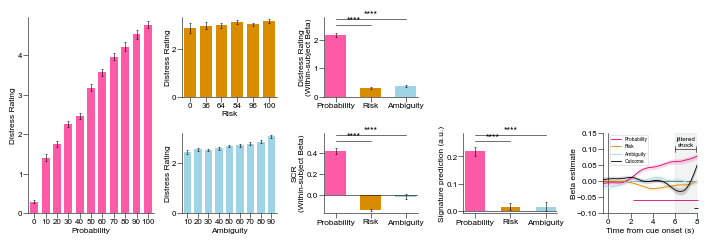

In [15]:
W_MM, H_MM = 170, 60
fig = plt.figure(figsize=(W_MM/25.4, H_MM/25.4), facecolor="white")

outer = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[0.5 + 0.5, 0.5 + 0.5 + 0.5],  # left block, right block
    left=0, right=1, bottom=0.12, top=0.95,
    wspace=0.15, hspace=0.45
)

# left block: 2 columns (col0 and col1)
gs_left = outer[:, 0].subgridspec(
    nrows=2, ncols=2,
    width_ratios=[0.6, 0.45],
    wspace=0.25, hspace=0.45
)

# right block: 3 columns (col2, col3, col4)
gs_right = outer[:, 1].subgridspec(
    nrows=2, ncols=3,
    width_ratios=[1, 1, 1],
    wspace=0.48, hspace=0.45
)

ax_prob   = fig.add_subplot(gs_left[:, 0])
ax_risk   = fig.add_subplot(gs_left[0, 1])
ax_amb    = fig.add_subplot(gs_left[1, 1])

ax_rating = fig.add_subplot(gs_right[0, 0])
ax_scl    = fig.add_subplot(gs_right[1, 0])

ax_Ceko   = fig.add_subplot(gs_right[1, 1])
ax_timecourse    = fig.add_subplot(gs_right[1, 2])

ax_ph3 = fig.add_subplot(gs_right[0, 1]); ax_ph3.axis("off")
ax_ph4 = fig.add_subplot(gs_right[0, 2]); ax_ph4.axis("off")


plot_prob_panel(ax_prob, prob_sum, colors_dict1)
plot_risk_panel(ax_risk, risk_sum, colors_dict1)
plot_amb_panel(ax_amb, amb_sum, colors_dict1)
plot_rating_panel(ax_rating, sum_rating, colors_dict, p_prob_vs_risk=p_h_prob_vs_risk, p_prob_vs_amb=p_h_prob_vs_amb, add_contrasts=True)
plot_scl_panel(ax_scl, sum_scl, colors_dict, p_prob_vs_risk=p_i_prob_vs_risk, p_prob_vs_amb=p_i_prob_vs_amb, add_contrasts=True)
plot_ceko_panel(ax_Ceko, summ_Ceko_NE, colors_dict, p_prob_vs_risk=p_k_prob_vs_risk, p_prob_vs_amb=p_k_prob_vs_amb, add_contrasts=True)
plot_timecourse(ax_timecourse, plot_df_Ceko_cue, alignment="cue")
add_significance_strips(ax_timecourse, times_ceko, sig_masks_ceko, colors=sig_colors)



fig.savefig(fig_out_dir / "Fig1_from_python_panel_l_updated_with_sem.pdf", bbox_inches="tight", facecolor="white")
plt.show()